In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import netCDF4 as nc
from scipy.stats import linregress

import sys
sys.path.append('/home/z5297792/UNSW-MRes/MRes/SEACOFS_dataset') 
from clim_functions import compute_core_mean


In [2]:
df_eddies = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/DOPPIO_SEACOFS_26yr_50m_vert_check/df_eddies_50m_vert_checked_processed.pkl')
df_tilt = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/DOPPIO_SEACOFS_26yr_50m_vert_check/df_tilt_vert_checked.pkl')
df_eddies = df_eddies.merge(
    df_tilt[['Eddy', 'Day', 'TiltDis', 'TiltDir']],
    how='left',
    left_on=['Eddy', 'Day'],
    right_on=['Eddy', 'Day']
)
dic_vert = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/DOPPIO_SEACOFS_26yr_50m_vert_check/dic_vert_doppio_50m_vert_checked.pkl')


In [3]:
# Field Data
fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_01461.nc'
dataset = nc.Dataset(fname)
lon_rho = np.transpose(dataset.variables['lon_rho'], axes=(1, 0))
lat_rho = np.transpose(dataset.variables['lat_rho'], axes=(1, 0))
mask_rho = np.transpose(dataset.variables['mask_rho'], axes=(1, 0))
h = np.transpose(dataset.variables['h'], axes=(1, 0))
f = np.transpose(dataset.variables['f'], axes=(1, 0))
angle = dataset.variables['angle'][0, 0]
z_r = np.load('/srv/scratch/z5297792/z_r.npy')
z_r = np.transpose(z_r, (1, 2, 0))
def distance(lat1, lon1, lat2, lon2):
    EARTH_RADIUS = 6357
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return EARTH_RADIUS * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
j_mid = lon_rho.shape[1] // 2
i_mid = lon_rho.shape[0] // 2
dx = distance(lat_rho[:-1, j_mid], lon_rho[:-1, j_mid],
              lat_rho[1:, j_mid], lon_rho[1:, j_mid])
dy = distance(lat_rho[i_mid, :-1], lon_rho[i_mid, :-1],
              lat_rho[i_mid, 1:], lon_rho[i_mid, 1:])
x_grid = np.insert(np.cumsum(dx), 0, 0)
y_grid = np.insert(np.cumsum(dy), 0, 0)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')


In [14]:
def panel(df_data, xcol, xlabel, legend_key, ax=None, xlim=None, split=None,
          reg_lo_override=None, reg_hi_override=None, scatter=False,
          xlim_flag=False, styles=None, linfit=False, xp=(10,90)):

    if ax is None:
        fig, ax = plt.subplots()

    df_data = df_data.copy()

    # Convert masked arrays to normal arrays with NaNs
    df_data[xcol] = np.ma.filled(np.ma.asarray(df_data[xcol]), np.nan)
    df_data['TiltDis'] = np.ma.filled(np.ma.asarray(df_data['TiltDis']), np.nan)

    if styles is None:
        styles = {
            'AE': {'line': 'darkred', 'fill': 'red'},
            'CE': {'line': 'navy',    'fill': 'blue'}
        }

    df_all = df_data.dropna(subset=[xcol])
    x = df_all[xcol].to_numpy(dtype=float)
    x_min, x_max = np.nanmin(x), np.nanmax(x)

    nbins = min(30, max(8, int(np.sqrt(len(x)))))
    bins = np.unique(np.nanquantile(x, np.linspace(0, 1, nbins + 1)))

    if len(bins) < 3:
        bins = np.linspace(x_min, x_max, 9)

    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    for cyc in ['AE', 'CE']:
        dfm = df_data[df_data.Cyc == cyc].dropna(subset=[xcol, 'TiltDis'])

        xval = dfm[xcol].to_numpy(dtype=float)
        tilt = dfm['TiltDis'].to_numpy(dtype=float)

        mask = np.isfinite(xval) & np.isfinite(tilt)
        xval, tilt = xval[mask], tilt[mask]

        mask = (xval >= x_min) & (xval <= x_max)
        xval, tilt = xval[mask], tilt[mask]

        d = np.digitize(xval, bins)

        med = np.array([
            np.nanmedian(tilt[d == i]) if np.any(d == i) else np.nan
            for i in range(1, len(bins))
        ])
        q25 = np.array([
            np.nanquantile(tilt[d == i], 0.25) if np.any(d == i) else np.nan
            for i in range(1, len(bins))
        ])
        q75 = np.array([
            np.nanquantile(tilt[d == i], 0.75) if np.any(d == i) else np.nan
            for i in range(1, len(bins))
        ])

        if scatter:
            ax.scatter(xval, tilt, s=1, alpha=0.08, color=styles[cyc]['fill'])

        msk = np.isfinite(med)

        ax.plot(
            bin_centers[msk], med[msk],
            lw=3,
            color=styles[cyc]['line'],
            alpha=.6
        )

        ax.fill_between(
            bin_centers[msk],
            q25[msk],
            q75[msk],
            color=styles[cyc]['fill'],
            alpha=0.10
        )
        if linfit:
            if split is None:
                lo, hi = np.nanpercentile(xval, [10, 90])
                reg_mask = (xval >= lo) & (xval <= hi)
    
                if reg_mask.sum() > 2:
                    m, c, *_ = linregress(xval[reg_mask], tilt[reg_mask])
                    xf = np.linspace(lo, hi, 200)
    
                    ax.plot(
                        xf, m * xf + c,
                        '--',
                        lw=3,
                        color=styles[cyc]['fill'],
                        label=fr'{cyc}: TD={m:.3g} {legend_key} {"$-$" if c < 0 else "$+$"} {abs(c):.3g}'
                    )
    
            else:
                lo, hi = np.nanpercentile(xval, [10, 90])
                hi2 = reg_hi_override if reg_hi_override is not None else hi
                lo2 = reg_lo_override if reg_lo_override is not None else lo
    
                for l, (a, b) in enumerate(zip([lo2, split], [split, hi2])):
                    reg_mask = (xval >= a) & (xval <= b)
    
                    if reg_mask.sum() > 2:
                        m, c, *_ = linregress(xval[reg_mask], tilt[reg_mask])
                        xf = np.linspace(a, b, 200)
    
                        ax.plot(
                            xf, m * xf + c,
                            ':' if l == 0 else '--',
                            lw=3,
                            color=styles[cyc]['fill'],
                            label=fr'{cyc}: TD={m:.3g} {legend_key} {"$-$" if c < 0 else "$+$"} {abs(c):.3g}'
                        )
            ax.legend(loc='upper right', ncol=2)

    if xlim is None:
        ax.set_xlim(*np.nanpercentile(df_data[xcol].to_numpy(dtype=float), [xp[0], xp[1]]))
        # ax.set_xlim(ax.get_xlim())
    else:
        ax.set_xlim(*xlim)

    if xlim_flag:
        ax.set_xlim(bin_centers.min(), bin_centers.max())


    ax.set_xlabel(xlabel)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    return ax
    

In [5]:
# Nbar
df_eddies = compute_core_mean(
    df_eddies,
    X_grid, Y_grid,
    mask_rho,
    base_path="/srv/scratch/z5297792/Climatology/N2s/Nbars_300m_depth",
    varname="Nbar",
    colname="Nbar"
)


In [33]:
# def add_top_bottom_speeds(df, dic_vert):

#     df = df.copy()
#     kmday_to_ms = 1000 / 86400

#     # Surface propagation
#     df['dx_top'] = df.groupby('Eddy')['xc'].diff()
#     df['dy_top'] = df.groupby('Eddy')['yc'].diff()
#     df['EddyProp'] = np.hypot(df.dx_top, df.dy_top) * kmday_to_ms

#     # Bottom centres
#     x_btm, y_btm = [], []

#     for r in df.itertuples():

#         try:
#             d = dic_vert[f'Eddy{int(r.Eddy)}'][f'Day{int(r.Day)}']

#             if len(d):
#                 d2 = d[d.Depth.abs() < 1000]
#                 row = d2.iloc[-1] if len(d2) else d.iloc[-1]
#                 x_btm.append(row.xc)
#                 y_btm.append(row.yc)
#             else:
#                 x_btm.append(np.nan)
#                 y_btm.append(np.nan)

#         except KeyError:
#             x_btm.append(np.nan)
#             y_btm.append(np.nan)

#     df['x_btm'] = x_btm
#     df['y_btm'] = y_btm

#     # Bottom propagation
#     df['dx_btm'] = df.groupby('Eddy')['x_btm'].diff()
#     df['dy_btm'] = df.groupby('Eddy')['y_btm'].diff()
#     df['btm_prop'] = np.hypot(df.dx_btm, df.dy_btm) * kmday_to_ms

#     # Separation metrics
#     df['sep_km'] = np.hypot(df.x_btm - df.xc,
#                             df.y_btm - df.yc)

#     df['sep_rate_ms'] = (
#         df.groupby('Eddy')['sep_km'].diff()
#         * kmday_to_ms
#     )

#     df['top_btm_diff'] = np.hypot(
#         df.dx_btm - df.dx_top,
#         df.dy_btm - df.dy_top
#     ) * kmday_to_ms

#     return df

def add_top_bottom_speeds(df, dic_vert, zmax=1000):
    df = df.copy()
    kmday_to_ms = 1000 / 86400

    # time step in days
    dt = df.groupby('Eddy')['Day'].diff()

    # surface propagation
    df['dx_top'] = df.groupby('Eddy')['xc'].diff()
    df['dy_top'] = df.groupby('Eddy')['yc'].diff()
    df['EddyProp'] = np.hypot(df.dx_top, df.dy_top) / dt * kmday_to_ms

    # bottom/deep centres
    x_btm, y_btm, z_btm = [], [], []

    for r in df.itertuples():
        try:
            d = dic_vert[f'Eddy{int(r.Eddy)}'][f'Day{int(r.Day)}']

            if len(d):
                d2 = d[d.Depth.abs() <= zmax]
                row = d2.iloc[-1] if len(d2) else d.iloc[-1]

                x_btm.append(row.xc)
                y_btm.append(row.yc)
                z_btm.append(row.Depth)
            else:
                x_btm.append(np.nan)
                y_btm.append(np.nan)
                z_btm.append(np.nan)

        except KeyError:
            x_btm.append(np.nan)
            y_btm.append(np.nan)
            z_btm.append(np.nan)

    df['x_btm'] = x_btm
    df['y_btm'] = y_btm
    df['z_btm'] = z_btm

    # bottom propagation
    df['dx_btm'] = df.groupby('Eddy')['x_btm'].diff()
    df['dy_btm'] = df.groupby('Eddy')['y_btm'].diff()
    df['btm_prop'] = np.hypot(df.dx_btm, df.dy_btm) / dt * kmday_to_ms

    # surface-bottom separation
    df['sep_km'] = np.hypot(df.x_btm - df.xc, df.y_btm - df.yc)
    df['sep_rate_ms'] = df.groupby('Eddy')['sep_km'].diff() / dt * kmday_to_ms

    # difference between surface and bottom propagation vectors
    df['top_btm_diff'] = np.hypot(
        df.dx_btm - df.dx_top,
        df.dy_btm - df.dy_top
    ) / dt * kmday_to_ms

    return df

df_eddies = add_top_bottom_speeds(df_eddies, dic_vert)


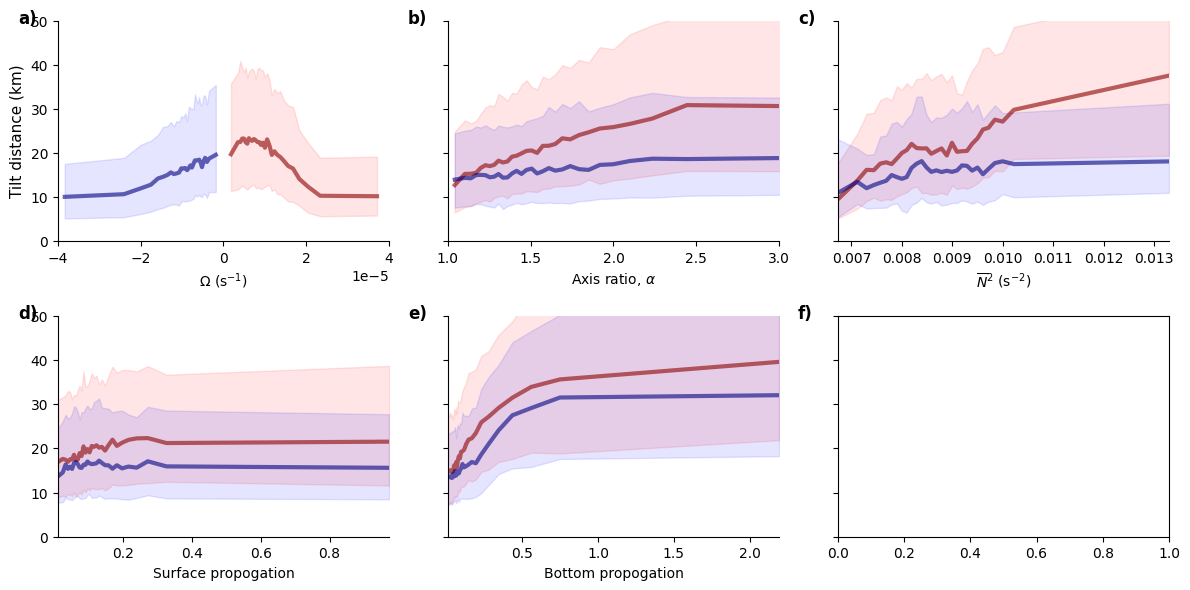

In [39]:
fig, axs = plt.subplots(
    2, 3,
    figsize=(12, 6),
    sharey=True,
    constrained_layout=False
)

axs = axs.flatten()

# =========================
# Omega
# =========================
ax = axs[0]

panel(
    df_eddies[df_eddies.Cyc=='AE'],
    'Omega',
    r'$\Omega$ (s$^{-1}$)',
    r'$\Omega$',
    ax=ax,
    xlim=(-4e-5, 4e-5),
    scatter=False,
    linfit=False,
    # xlim_flag=True
)

panel(
    df_eddies[df_eddies.Cyc=='CE'],
    'Omega',
    r'$\Omega$ (s$^{-1}$)',
    r'$\Omega$',
    ax=ax,
    xlim=(-4e-5, 4e-5),
    scatter=False,
    linfit=False,
    # xlim_flag=True
)

# ax.set_xlim=(-4e-5, 4e-5)
ax.set_ylabel('Tilt distance (km)', fontsize=11)
ax.set_ylim(0, 50)


# =========================
# Aspect ratio
# =========================
ax = axs[1]

panel(
    df_eddies,
    'AR',
    r'Axis ratio, $\alpha$',
    r'$\alpha$',
    ax=ax,
    xlim=(1, 3),
    scatter=False,
    linfit=False,
    xp=(0,90)
)

# =========================
# Stratification
# =========================
ax = axs[2]

panel(
    df_eddies,
    'Nbar',
    r'$\overline{N}^2$ (s$^{-2}$)',
    r'$\overline{N}^2$',
    ax=ax,
    scatter=False,
    linfit=False,
    # xp=(0,100)
    xlim_flag=True
)

# =========================
# Stratification
# =========================
ax = axs[3]

panel(
    df_eddies,
    'EddyProp',
    r'Surface propogation',
    r'',
    ax=ax,
    scatter=False,
    linfit=False,
    # xp=(0,100)
    xlim_flag=True
)

# =========================
# Stratification
# =========================
ax = axs[4]

panel(
    df_eddies,
    'btm_prop',
    r'Bottom propogation',
    r'',
    ax=ax,
    scatter=False,
    linfit=False,
    # xp=(0,100)
    xlim_flag=True
)

tags = ['a)', 'b)', 'c)', 'd)', 'e)', 'f)']
for k, ax in enumerate(axs):
    ax.text(
        -0.12, 1.05, tags[k],
        transform=ax.transAxes,
        fontsize=12,
        fontweight='bold',
        va='top',
        ha='left'
    )


# axs[3], axs[4], axs[5]
# add more panels here later

plt.tight_layout()
plt.show()
